Instalación de librerias

In [18]:
# Importación de las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, silhouette_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from scipy.optimize import linear_sum_assignment

Carga y preparación de datos

In [19]:
# Descarga del dataset MNIST, conversión a float y normalización al rango [0, 1]
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(np.int64)

# División estratificada de los datos reservando 10,000 muestras para el conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y)

Análisis exploratorio

{np.int64(0): np.int64(5917), np.int64(1): np.int64(6752), np.int64(2): np.int64(5991), np.int64(3): np.int64(6121), np.int64(4): np.int64(5849), np.int64(5): np.int64(5411), np.int64(6): np.int64(5894), np.int64(7): np.int64(6251), np.int64(8): np.int64(5850), np.int64(9): np.int64(5964)}


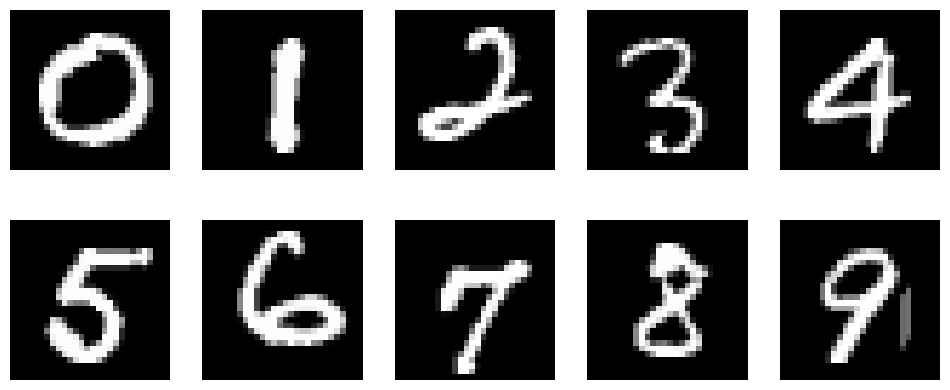

In [20]:
# Conteo de muestras por cada clase para verificar el balance del conjunto de entrenamiento
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

# Visualización gráfica de una muestra representativa de cada dígito (0 al 9)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[y_train == i][0].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

Función de evaluación

In [28]:
# Funciones de evaluación y alineación mediante el algoritmo húngaro
def evaluate_with_mapping(y_true, y_pred, mapping):
    aligned_preds = np.array([mapping.get(p, -1) for p in y_pred])
    correct = np.sum(aligned_preds == y_true)
    return correct / len(y_true)

def align_clusters_hungarian(y_true, y_pred, n_clusters):
    cm = np.zeros((10, n_clusters), dtype=int)
    for i in range(10):
        for j in range(n_clusters):
            cm[i, j] = np.sum((y_true == i) & (y_pred == j))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return mapping

Dimensión del espacio: ¿Antes o después de reducir?

In [22]:
# Búsqueda de la dimensión óptima evaluando PCA con diferentes números de componentes
dims_to_test = [10, 20, 40, 60, 100, 150, X_train.shape[1]]
dim_experiments = []

for d in dims_to_test:
    if d < X_train.shape[1]:
        pca_temp = PCA(n_components=d, random_state=42)
        X_tr = pca_temp.fit_transform(X_train)
    else:
        X_tr = X_train

    km_temp = KMeans(n_clusters=10, random_state=42, n_init=10)
    preds_temp = km_temp.fit_predict(X_tr)
    mapping_temp = align_clusters_hungarian(y_train, preds_temp, 10)
    acc = evaluate_with_mapping(y_train, preds_temp, mapping_temp)

    dim_experiments.append({'dim': d, 'acc': acc})
    print(f"Dimension: {d} | Class-to-Cluster Acc (K=10): {acc:.4f}")

best_dim_idx = int(np.argmax([exp['acc'] for exp in dim_experiments]))
optimal_dim = dim_experiments[best_dim_idx]['dim']
print(f"\nDimension optima seleccionada: {optimal_dim}")

# Transformación definitiva de train y test con la dimensión óptima seleccionada
pca_final = PCA(n_components=optimal_dim, random_state=42)
X_train_pca = pca_final.fit_transform(X_train)
X_test_pca = pca_final.transform(X_test)

Dimension: 10 | Class-to-Cluster Acc (K=10): 0.5009
Dimension: 20 | Class-to-Cluster Acc (K=10): 0.5264
Dimension: 40 | Class-to-Cluster Acc (K=10): 0.5332
Dimension: 60 | Class-to-Cluster Acc (K=10): 0.5333
Dimension: 100 | Class-to-Cluster Acc (K=10): 0.5334
Dimension: 150 | Class-to-Cluster Acc (K=10): 0.5331
Dimension: 784 | Class-to-Cluster Acc (K=10): 0.5331

Dimension optima seleccionada: 100


Búsqueda de K y consistencia Train-Test

In [23]:
# Evaluación de múltiples valores de K
k_values = [8, 10, 12, 15, 20, 25, 30]
k_experiments = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    train_preds = km.fit_predict(X_train_pca)
    test_preds = km.predict(X_test_pca)

    # El mapeo se aprende con train y se evalúa tanto en train como en test
    train_mapping = align_clusters_hungarian(y_train, train_preds, k)
    train_acc = evaluate_with_mapping(y_train, train_preds, train_mapping)
    test_acc = evaluate_with_mapping(y_test, test_preds, train_mapping)

    sample_idx = np.random.choice(len(X_train_pca), size=5000, replace=False)
    sil = silhouette_score(X_train_pca[sample_idx], train_preds[sample_idx])
    ch = calinski_harabasz_score(X_train_pca, train_preds)

    k_experiments.append({
        'k': k,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'silhouette': sil,
        'calinski': ch,
        'inertia': km.inertia_
    })
    print(f"K={k} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Silhouette: {sil:.4f} | CH: {ch:.1f}")

df_results = pd.DataFrame(k_experiments)
df_results = df_results[['k', 'train_acc', 'test_acc', 'silhouette', 'calinski', 'inertia']]
df_results.columns = ['K', 'Train Acc', 'Test Acc', 'Silhouette', 'Calinski-Harabasz', 'Inercia']
display(df_results.style.background_gradient(subset=['Train Acc', 'Test Acc', 'Silhouette'], cmap='Blues'))

gmm = GaussianMixture(n_components=10, random_state=42, covariance_type='full', max_iter=100)
gmm_preds = gmm.fit_predict(X_train_pca)
gmm_mapping = align_clusters_hungarian(y_train, gmm_preds, 10)
gmm_acc = evaluate_with_mapping(y_train, gmm_preds, gmm_mapping)
print(f"\nClass-to-Cluster Accuracy con GMM (K=10): {gmm_acc:.4f}")

K=8 | Train Acc: 0.5780 | Test Acc: 0.5828 | Silhouette: 0.0832 | CH: 2899.4
K=10 | Train Acc: 0.5334 | Test Acc: 0.5342 | Silhouette: 0.0688 | CH: 2596.4
K=12 | Train Acc: 0.5058 | Test Acc: 0.5016 | Silhouette: 0.0694 | CH: 2376.7
K=15 | Train Acc: 0.4772 | Test Acc: 0.4751 | Silhouette: 0.0747 | CH: 2116.0
K=20 | Train Acc: 0.3836 | Test Acc: 0.3847 | Silhouette: 0.0703 | CH: 1811.1
K=25 | Train Acc: 0.3310 | Test Acc: 0.3332 | Silhouette: 0.0748 | CH: 1597.8
K=30 | Train Acc: 0.2920 | Test Acc: 0.2871 | Silhouette: 0.0771 | CH: 1421.5


,K,Train Acc,Test Acc,Silhouette,Calinski-Harabasz,Inercia
0,8,0.578017,0.582800,0.083239,2899.413423,2164241.000000
1,10,0.533450,0.534200,0.068843,2596.356798,2084482.500000
2,12,0.505750,0.501600,0.069419,2376.688961,2017269.125000
3,15,0.477217,0.475100,0.074680,2115.989493,1938896.000000
4,20,0.383617,0.384700,0.070290,1811.080545,1840519.375000
5,25,0.330950,0.333200,0.074845,1597.784456,1766782.875000
6,30,0.291967,0.287100,0.077136,1421.458337,1716520.750000



Class-to-Cluster Accuracy con GMM (K=10): 0.5697


Gráfica de evolución del Accuracy según K

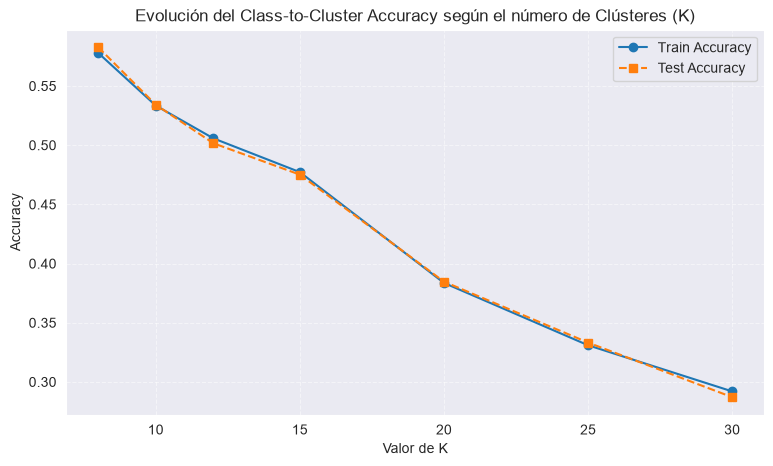

In [24]:
# Generación de la gráfica comparativa del rendimiento en entrenamiento y prueba frente a K
k_list = [exp['k'] for exp in k_experiments]
train_acc_list = [exp['train_acc'] for exp in k_experiments]
test_acc_list = [exp['test_acc'] for exp in k_experiments]

plt.figure(figsize=(9, 5))
plt.plot(k_list, train_acc_list, marker='o', linestyle='-', label='Train Accuracy')
plt.plot(k_list, test_acc_list, marker='s', linestyle='--', label='Test Accuracy')
plt.title('Evolución del Class-to-Cluster Accuracy según el número de Clústeres (K)')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Matrices de Confusión y Heatmaps

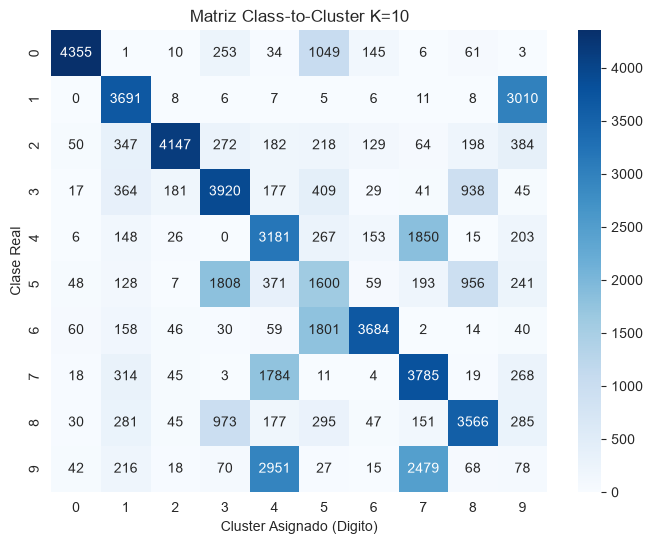

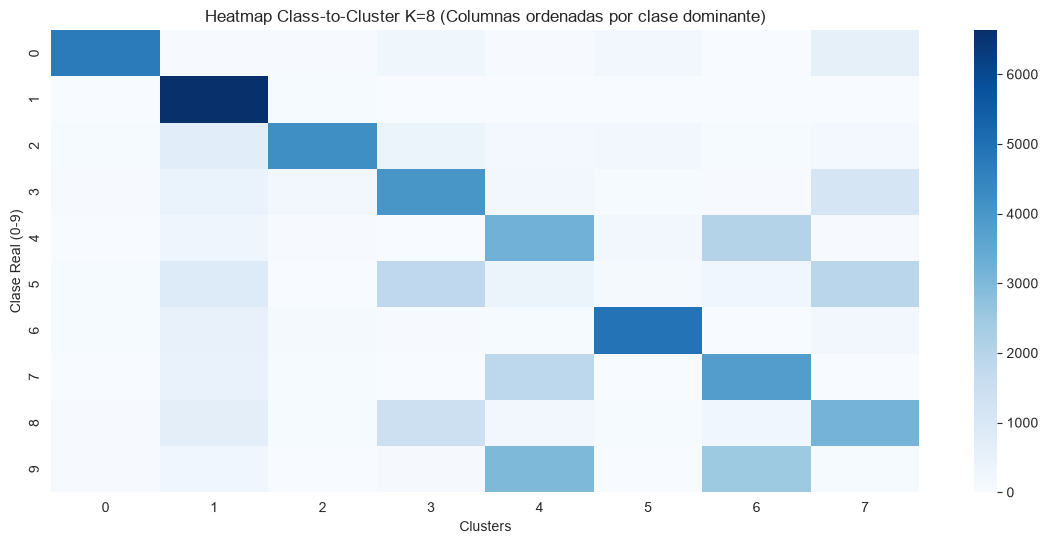

In [25]:
# Generación de la matriz de confusión para K=10 fijo
kmeans_10 = KMeans(n_clusters=10, random_state=42, n_init=10)
train_c10 = kmeans_10.fit_predict(X_train_pca)
test_c10 = kmeans_10.predict(X_test_pca)

map_c10 = align_clusters_hungarian(y_train, train_c10, 10)
train_c10_aligned = np.array([map_c10.get(p, -1) for p in train_c10])
cm_c10 = confusion_matrix(y_train, train_c10_aligned, labels=np.arange(10))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_c10, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz Class-to-Cluster K=10')
plt.xlabel('Cluster Asignado (Digito)')
plt.ylabel('Clase Real')
plt.show()

# Selección dinámica del mejor K obtenido en la experimentación
best_k_idx = int(np.argmax([exp['train_acc'] for exp in k_experiments]))
best_k = k_experiments[best_k_idx]['k']
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_c_best = kmeans_best.fit_predict(X_train_pca)

best_mapping = align_clusters_hungarian(y_train, train_c_best, best_k)
dominant_classes = [best_mapping[c] for c in range(best_k)]
sorted_cols = np.lexsort((np.arange(best_k), dominant_classes))

cm_best_raw = np.array([[np.sum((y_train == r) & (train_c_best == c)) for c in range(best_k)] for r in range(10)])
cm_best_sorted = cm_best_raw[:, sorted_cols]

plt.figure(figsize=(14, 6))
sns.heatmap(cm_best_sorted, annot=False, cmap='Blues')
plt.title(f'Heatmap Class-to-Cluster K={best_k} (Columnas ordenadas por clase dominante)')
plt.xlabel('Clusters')
plt.ylabel('Clase Real (0-9)')
plt.show()

Visualización en 2D

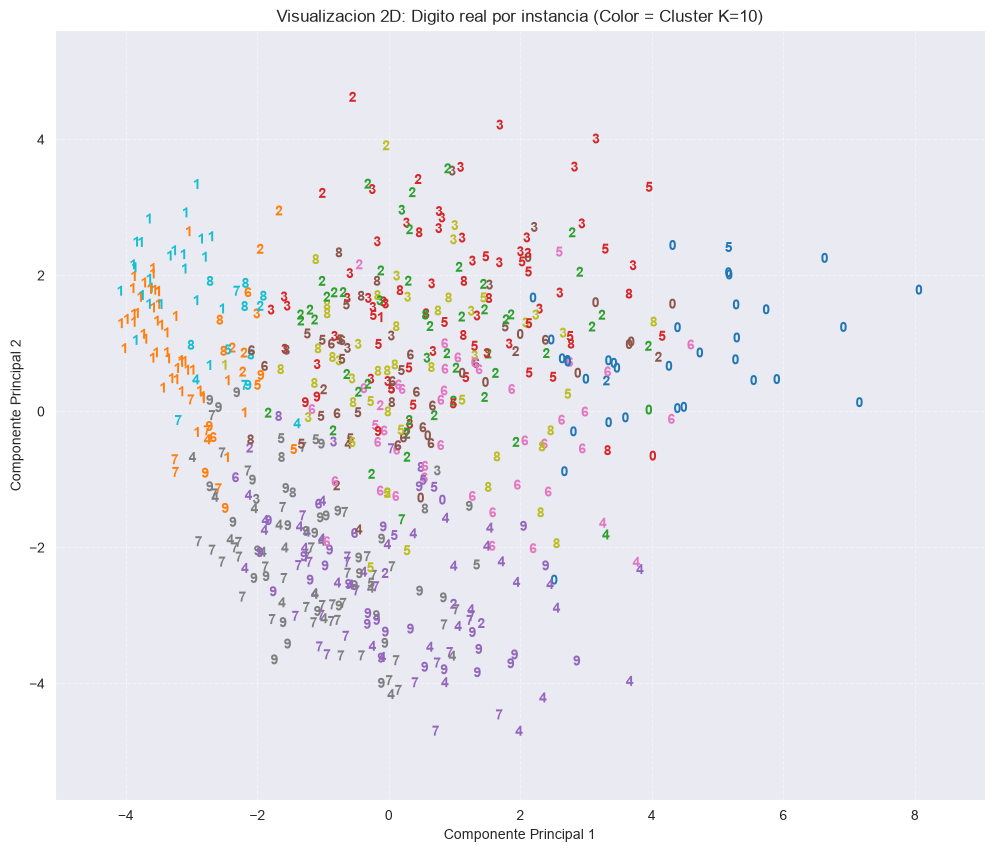

In [26]:
# Reducción a 2 dimensiones mediante PCA para representación gráfica en 2D
pca_2 = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2.fit_transform(X_train)

# Selección de una submuestra aleatoria para mejor visualización
sample_size = 600
sample_idx = np.random.choice(len(X_train_pca2), sample_size, replace=False)

X_sub = X_train_pca2[sample_idx]
y_sub = y_train[sample_idx]
clusters_sub = train_c10_aligned[sample_idx]

# Creación del gráfico de dispersión mostrando el dígito real etiquetado con colores por clúster
plt.figure(figsize=(12, 10))
palette = sns.color_palette("tab10", 10)

for i in range(sample_size):
    plt.text(
        X_sub[i, 0],
        X_sub[i, 1],
        str(y_sub[i]),
        color=palette[clusters_sub[i]],
        fontdict={'weight': 'bold', 'size': 10},
        ha='center',
        va='center'
    )

plt.xlim(X_sub[:, 0].min() - 1, X_sub[:, 0].max() + 1)
plt.ylim(X_sub[:, 1].min() - 1, X_sub[:, 1].max() + 1)
plt.title("Visualizacion 2D: Digito real por instancia (Color = Cluster K=10)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Asignación de nuevas instancias (Inferencia out-of-sample)

In [27]:
def predict_new_instance(image_raw, pca_model, kmeans_model, mapping_dict):
    # Proyecta la nueva imagen y predice su cluster evitando data leakage
    if image_raw.ndim == 1:
        image_raw = image_raw.reshape(1, -1)
    image_pca = pca_model.transform(image_raw)
    cluster_id = kmeans_model.predict(image_pca)[0]
    predicted_digit = mapping_dict[cluster_id]
    return cluster_id, predicted_digit

# Probamos la inferencia con una instancia del conjunto de test
sample_test_idx = 0
sample_img = X_test[sample_test_idx]
c_pred, d_pred = predict_new_instance(sample_img, pca_final, kmeans_best, best_mapping)
print(f"Instancia de test 0 -> Cluster: {c_pred} | Digito asignado: {d_pred} | Digito real: {y_test[sample_test_idx]}")

Instancia de test 0 -> Cluster: 5 | Digito asignado: 7 | Digito real: 7
